# Chapter 4.2: User Behavior Modeling

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand the challenge of modeling **long user behavior sequences** (10K+ interactions)
2. Implement **SIM** (Search-based Interest Model, Alibaba 2020) with GSU and ESU components
3. Build **ETA** (End-to-End Target Attention) with hash-based efficient attention
4. Implement **SDIM** (Sampling-based Deep Interest Modeling) for efficient behavior modeling
5. Understand hierarchical and memory-based approaches (**HPMN**, **MIMN**)
6. Apply **UBR4CTR** (User Behavior Retrieval) for CTR prediction
7. Evaluate trade-offs between accuracy and latency for different approaches

## Prerequisites

- Understanding of attention mechanisms and Transformers
- Familiarity with DIN (Deep Interest Network) concepts
- Basic knowledge of hashing and retrieval methods

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part4/chapter_4.2_user_behavior.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part4/chapter_4.2_user_behavior.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple
import time

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cpu')

PyTorch version: 2.2.2


## 1. The Long User Behavior Sequence Challenge

In industrial recommendation systems, users may have thousands to tens of thousands of historical interactions. Standard attention mechanisms have $O(n^2)$ complexity, making them impractical for such long sequences.

### Key Approaches

| Approach | Method | Complexity | Accuracy |
|----------|--------|------------|----------|
| Truncation | Keep last $k$ behaviors | $O(k)$ | Low (loses long-term) |
| **SIM** | Two-stage search | $O(n + k^2)$ | High |
| **ETA** | Hash-based attention | $O(n)$ | Medium-High |
| **SDIM** | Sampling-based | $O(n)$ | Medium-High |
| **MIMN** | Memory network | $O(m)$ | Medium |

where $n$ is the full sequence length, $k$ is the retrieved subsequence length, and $m$ is the memory size.

In [2]:
def generate_behavior_data(num_users=1000, num_items=5000, max_seq_len=500,
                           num_categories=50, seed=42):
    """Generate synthetic user behavior data.
    
    Returns:
        user_histories: dict of user_id -> list of (item_id, category_id, timestamp)
        target_items: (num_users,) target item for each user
        target_categories: (num_users,) category of target item
        labels: (num_users,) click labels
    """
    np.random.seed(seed)
    item_categories = np.random.randint(0, num_categories, size=num_items)
    
    user_histories = {}
    target_items = []
    target_categories = []
    labels = []
    
    for uid in range(num_users):
        seq_len = np.random.randint(50, max_seq_len)
        # Users tend to interact with items from a few preferred categories
        preferred_cats = np.random.choice(num_categories, size=5, replace=False)
        
        history = []
        for t in range(seq_len):
            if np.random.rand() < 0.7:  # 70% from preferred categories
                cat = np.random.choice(preferred_cats)
                candidates = np.where(item_categories == cat)[0]
                if len(candidates) > 0:
                    item_id = np.random.choice(candidates)
                else:
                    item_id = np.random.randint(0, num_items)
            else:
                item_id = np.random.randint(0, num_items)
            history.append((item_id, item_categories[item_id], t))
        
        user_histories[uid] = history
        
        # Target item
        target_item = np.random.randint(0, num_items)
        target_items.append(target_item)
        target_categories.append(item_categories[target_item])
        
        # Label: higher probability if target category matches preferred categories
        if item_categories[target_item] in preferred_cats:
            labels.append(float(np.random.rand() < 0.6))
        else:
            labels.append(float(np.random.rand() < 0.2))
    
    return user_histories, np.array(target_items), np.array(target_categories), np.array(labels)


NUM_ITEMS = 5000
NUM_CATEGORIES = 50
EMBED_DIM = 32

user_histories, target_items, target_categories, labels = generate_behavior_data()
print(f"Users: {len(user_histories)}")
print(f"Avg sequence length: {np.mean([len(h) for h in user_histories.values()]):.1f}")
print(f"Positive rate: {labels.mean():.3f}")

Users: 1000
Avg sequence length: 277.4
Positive rate: 0.232


## 2. SIM: Search-based Interest Model (Alibaba, 2020)

SIM proposes a two-stage approach to handle ultra-long user behavior sequences:

### Stage 1: General Search Unit (GSU)
Efficiently retrieves a relevant subsequence from the full behavior history using category-based filtering or inner-product search.

### Stage 2: Exact Search Unit (ESU)
Applies target attention (like DIN) on the retrieved short subsequence.

$$\text{GSU: } S_k = \text{TopK}(\{\text{sim}(\mathbf{e}_i, \mathbf{e}_t) : i \in \text{History}\})$$

$$\text{ESU: } \mathbf{u} = \sum_{i \in S_k} \alpha_i \mathbf{v}_i, \quad \alpha_i = \frac{\exp(f(\mathbf{v}_i, \mathbf{v}_t))}{\sum_{j \in S_k} \exp(f(\mathbf{v}_j, \mathbf{v}_t))}$$

> **💡 Concept:** SIM decouples the search problem (finding relevant behaviors) from the modeling problem (learning attention weights), enabling efficient processing of very long histories.

In [3]:
class GeneralSearchUnit(nn.Module):
    """SIM's General Search Unit (GSU).
    
    Two modes:
    - 'hard': Category-based filtering (hard search)
    - 'soft': Inner-product based top-k retrieval (soft search)
    """
    def __init__(self, num_items: int, num_categories: int, embed_dim: int,
                 search_mode: str = 'soft', top_k: int = 50):
        super().__init__()
        self.search_mode = search_mode
        self.top_k = top_k
        self.item_embedding = nn.Embedding(num_items, embed_dim)
        self.category_embedding = nn.Embedding(num_categories, embed_dim)
        # For soft search, a lightweight projection
        self.search_proj = nn.Linear(embed_dim, embed_dim, bias=False)
    
    def forward(self, behavior_items: torch.Tensor, behavior_cats: torch.Tensor,
                target_item: torch.Tensor, target_cat: torch.Tensor,
                behavior_mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Args:
            behavior_items: (batch, seq_len) item IDs
            behavior_cats: (batch, seq_len) category IDs
            target_item: (batch,) target item ID
            target_cat: (batch,) target category ID
            behavior_mask: (batch, seq_len) 1 for valid, 0 for padding
        
        Returns:
            retrieved_embeds: (batch, top_k, embed_dim)
            retrieved_mask: (batch, top_k)
            search_scores: (batch, top_k) for auxiliary loss
        """
        batch_size, seq_len = behavior_items.shape
        
        if self.search_mode == 'hard':
            # Hard search: filter by matching category
            target_cat_expanded = target_cat.unsqueeze(1).expand_as(behavior_cats)
            cat_match = (behavior_cats == target_cat_expanded).float() * behavior_mask
            # Get top-k matching positions
            scores = cat_match + torch.rand_like(cat_match) * 0.01  # break ties randomly
        else:
            # Soft search: inner product between behavior and target embeddings
            behav_embeds = self.item_embedding(behavior_items)  # (batch, seq_len, dim)
            target_embed = self.search_proj(self.item_embedding(target_item))  # (batch, dim)
            scores = torch.bmm(behav_embeds, target_embed.unsqueeze(-1)).squeeze(-1)  # (batch, seq_len)
            scores = scores * behavior_mask + (1 - behavior_mask) * (-1e9)
        
        # Top-k retrieval
        k = min(self.top_k, seq_len)
        topk_scores, topk_indices = torch.topk(scores, k, dim=1)  # (batch, k)
        
        # Gather retrieved item embeddings
        all_embeds = self.item_embedding(behavior_items)  # (batch, seq_len, dim)
        topk_indices_expanded = topk_indices.unsqueeze(-1).expand(-1, -1, all_embeds.size(-1))
        retrieved_embeds = torch.gather(all_embeds, 1, topk_indices_expanded)
        
        # Gather masks
        retrieved_mask = torch.gather(behavior_mask, 1, topk_indices)
        
        return retrieved_embeds, retrieved_mask, topk_scores


class ExactSearchUnit(nn.Module):
    """SIM's Exact Search Unit (ESU) - target attention on retrieved subsequence."""
    def __init__(self, embed_dim: int, hidden_dim: int = 64):
        super().__init__()
        # DIN-style attention
        self.attention = nn.Sequential(
            nn.Linear(embed_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, retrieved_embeds: torch.Tensor, target_embed: torch.Tensor,
                mask: torch.Tensor) -> torch.Tensor:
        """
        Args:
            retrieved_embeds: (batch, k, embed_dim)
            target_embed: (batch, embed_dim)
            mask: (batch, k)
        Returns:
            user_interest: (batch, embed_dim)
        """
        k = retrieved_embeds.size(1)
        target_expanded = target_embed.unsqueeze(1).expand_as(retrieved_embeds)
        
        # Attention input: [behavior, target, behavior * target]
        attn_input = torch.cat([
            retrieved_embeds,
            target_expanded,
            retrieved_embeds * target_expanded
        ], dim=-1)
        
        attn_scores = self.attention(attn_input).squeeze(-1)  # (batch, k)
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(attn_scores, dim=-1)  # (batch, k)
        
        user_interest = torch.bmm(attn_weights.unsqueeze(1), retrieved_embeds).squeeze(1)
        return user_interest


class SIM(nn.Module):
    """Search-based Interest Model (SIM)."""
    def __init__(self, num_items: int, num_categories: int, embed_dim: int,
                 top_k: int = 50, search_mode: str = 'soft'):
        super().__init__()
        self.gsu = GeneralSearchUnit(num_items, num_categories, embed_dim, search_mode, top_k)
        self.esu = ExactSearchUnit(embed_dim)
        self.target_embedding = nn.Embedding(num_items, embed_dim)
        
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, behavior_items, behavior_cats, target_item, target_cat, behavior_mask):
        # Stage 1: GSU - retrieve relevant behaviors
        retrieved_embeds, retrieved_mask, search_scores = self.gsu(
            behavior_items, behavior_cats, target_item, target_cat, behavior_mask
        )
        
        # Stage 2: ESU - target attention on retrieved behaviors
        target_embed = self.target_embedding(target_item)
        user_interest = self.esu(retrieved_embeds, target_embed, retrieved_mask)
        
        # Prediction
        combined = torch.cat([user_interest, target_embed], dim=-1)
        logit = self.mlp(combined).squeeze(-1)
        return logit, search_scores


# Test SIM
model_sim = SIM(NUM_ITEMS, NUM_CATEGORIES, EMBED_DIM, top_k=50, search_mode='soft')
batch_items = torch.randint(0, NUM_ITEMS, (16, 200))
batch_cats = torch.randint(0, NUM_CATEGORIES, (16, 200))
batch_target = torch.randint(0, NUM_ITEMS, (16,))
batch_target_cat = torch.randint(0, NUM_CATEGORIES, (16,))
batch_mask = torch.ones(16, 200)

logits, scores = model_sim(batch_items, batch_cats, batch_target, batch_target_cat, batch_mask)
print(f"SIM output shape: {logits.shape}")
print(f"SIM parameters: {sum(p.numel() for p in model_sim.parameters()):,}")

SIM output shape: torch.Size([16])
SIM parameters: 345,538


## 3. ETA: End-to-End Target Attention

ETA uses **SimHash** (locality-sensitive hashing) to efficiently compute approximate target attention over long sequences in $O(n)$ time.

### SimHash for Efficient Attention

$$\text{hash}(\mathbf{x}) = \text{sign}(R \mathbf{x})$$

where $R$ is a random projection matrix. Two vectors with high cosine similarity will have similar hash codes.

The Hamming distance between hash codes approximates the angular distance:

$$P[h_r(\mathbf{x}) = h_r(\mathbf{y})] = 1 - \frac{\theta(\mathbf{x}, \mathbf{y})}{\pi}$$

> **🔑 Pro Tip:** ETA achieves near-linear complexity while maintaining competitive accuracy by using hash-based filtering as an attention approximation, not just a pre-filter.

In [4]:
class SimHashAttention(nn.Module):
    """SimHash-based efficient target attention for ETA."""
    def __init__(self, embed_dim: int, num_hashes: int = 32):
        super().__init__()
        self.num_hashes = num_hashes
        # Random projection matrix (fixed)
        self.register_buffer(
            'random_proj',
            torch.randn(embed_dim, num_hashes)
        )
    
    def compute_hash(self, x: torch.Tensor) -> torch.Tensor:
        """Compute SimHash binary codes."""
        projected = x @ self.random_proj  # (..., num_hashes)
        return (projected > 0).float()
    
    def hamming_similarity(self, hash_a: torch.Tensor, hash_b: torch.Tensor) -> torch.Tensor:
        """Compute similarity from Hamming distance."""
        # Fraction of matching bits
        return (hash_a == hash_b).float().mean(dim=-1)
    
    def forward(self, behavior_embeds: torch.Tensor, target_embed: torch.Tensor,
                mask: torch.Tensor, top_k: int = 50) -> torch.Tensor:
        """
        Args:
            behavior_embeds: (batch, seq_len, embed_dim)
            target_embed: (batch, embed_dim)
            mask: (batch, seq_len)
            top_k: number of items to attend to
        """
        batch_size, seq_len, _ = behavior_embeds.shape
        
        # Compute hash codes
        behav_hash = self.compute_hash(behavior_embeds)  # (batch, seq_len, num_hashes)
        target_hash = self.compute_hash(target_embed).unsqueeze(1)  # (batch, 1, num_hashes)
        
        # Hamming similarity
        sim = self.hamming_similarity(behav_hash, target_hash)  # (batch, seq_len)
        sim = sim * mask + (1 - mask) * (-1.0)
        
        # Top-k selection
        k = min(top_k, seq_len)
        topk_sim, topk_idx = torch.topk(sim, k, dim=1)
        
        # Gather top-k embeddings
        topk_idx_expanded = topk_idx.unsqueeze(-1).expand(-1, -1, behavior_embeds.size(-1))
        topk_embeds = torch.gather(behavior_embeds, 1, topk_idx_expanded)
        
        # Standard attention on top-k
        target_expanded = target_embed.unsqueeze(1).expand_as(topk_embeds)
        attn_scores = (topk_embeds * target_expanded).sum(dim=-1)  # (batch, k)
        topk_mask = torch.gather(mask, 1, topk_idx)
        attn_scores = attn_scores.masked_fill(topk_mask == 0, -1e9)
        attn_weights = F.softmax(attn_scores, dim=-1)
        
        return torch.bmm(attn_weights.unsqueeze(1), topk_embeds).squeeze(1)


class ETA(nn.Module):
    """End-to-End Target Attention model."""
    def __init__(self, num_items: int, embed_dim: int, num_hashes: int = 32, top_k: int = 50):
        super().__init__()
        self.item_embedding = nn.Embedding(num_items, embed_dim)
        self.hash_attention = SimHashAttention(embed_dim, num_hashes)
        self.top_k = top_k
        
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, behavior_items, target_item, behavior_mask):
        behav_embeds = self.item_embedding(behavior_items)
        target_embed = self.item_embedding(target_item)
        
        user_interest = self.hash_attention(behav_embeds, target_embed, behavior_mask, self.top_k)
        combined = torch.cat([user_interest, target_embed], dim=-1)
        return self.mlp(combined).squeeze(-1)


model_eta = ETA(NUM_ITEMS, EMBED_DIM, num_hashes=32, top_k=50)
logits = model_eta(batch_items, batch_target, batch_mask)
print(f"ETA output shape: {logits.shape}")
print(f"ETA parameters: {sum(p.numel() for p in model_eta.parameters()):,}")

ETA output shape: torch.Size([16])
ETA parameters: 176,641


## 4. SDIM: Sampling-based Deep Interest Modeling

SDIM uses multi-round **hash-based sampling** to approximate the attention distribution, avoiding explicit top-k selection.

### Core Idea

Instead of computing attention weights for all behaviors, SDIM:
1. Hashes both behaviors and target into buckets
2. Samples behaviors that fall into the same bucket as the target
3. Computes attention only on the sampled subset

$$P(i \text{ sampled}) \propto \text{sim}(\mathbf{h}_i, \mathbf{h}_t)$$

> **⚠️ Common Pitfall:** Hash-based methods require careful hash function design. Too few hash bits lead to many collisions (noisy samples), while too many lead to empty buckets (missing relevant behaviors).

In [5]:
class SDIM(nn.Module):
    """Sampling-based Deep Interest Modeling."""
    def __init__(self, num_items: int, embed_dim: int, num_hash_bits: int = 16,
                 num_hash_rounds: int = 4, sample_size: int = 50):
        super().__init__()
        self.num_hash_rounds = num_hash_rounds
        self.sample_size = sample_size
        self.num_hash_bits = num_hash_bits
        
        self.item_embedding = nn.Embedding(num_items, embed_dim)
        
        # Multiple hash functions (random projections)
        self.hash_projections = nn.ParameterList([
            nn.Parameter(torch.randn(embed_dim, num_hash_bits), requires_grad=False)
            for _ in range(num_hash_rounds)
        ])
        
        self.attention_mlp = nn.Sequential(
            nn.Linear(embed_dim * 3, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
        self.output_mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def _hash_sample(self, behavior_embeds, target_embed, mask, round_idx):
        """Hash-based sampling for one round."""
        proj = self.hash_projections[round_idx]
        
        # Compute hash codes
        behav_hash = (behavior_embeds @ proj > 0).float()  # (batch, seq, bits)
        target_hash = (target_embed @ proj > 0).float().unsqueeze(1)  # (batch, 1, bits)
        
        # Hamming similarity as sampling probability
        similarity = (behav_hash == target_hash).float().mean(dim=-1)  # (batch, seq)
        similarity = similarity * mask
        
        return similarity
    
    def forward(self, behavior_items, target_item, behavior_mask):
        behav_embeds = self.item_embedding(behavior_items)
        target_embed = self.item_embedding(target_item)
        
        # Multi-round hash sampling
        total_similarity = torch.zeros(behavior_items.size(0), behavior_items.size(1))
        for r in range(self.num_hash_rounds):
            total_similarity += self._hash_sample(behav_embeds, target_embed, behavior_mask, r)
        total_similarity /= self.num_hash_rounds
        
        # Select top-k based on accumulated hash similarity
        k = min(self.sample_size, behavior_items.size(1))
        _, topk_idx = torch.topk(total_similarity, k, dim=1)
        
        topk_idx_expanded = topk_idx.unsqueeze(-1).expand(-1, -1, behav_embeds.size(-1))
        sampled_embeds = torch.gather(behav_embeds, 1, topk_idx_expanded)
        sampled_mask = torch.gather(behavior_mask, 1, topk_idx)
        
        # Attention on sampled items
        target_expanded = target_embed.unsqueeze(1).expand_as(sampled_embeds)
        attn_input = torch.cat([sampled_embeds, target_expanded, sampled_embeds * target_expanded], dim=-1)
        attn_scores = self.attention_mlp(attn_input).squeeze(-1)
        attn_scores = attn_scores.masked_fill(sampled_mask == 0, -1e9)
        attn_weights = F.softmax(attn_scores, dim=-1)
        
        user_interest = torch.bmm(attn_weights.unsqueeze(1), sampled_embeds).squeeze(1)
        combined = torch.cat([user_interest, target_embed], dim=-1)
        return self.output_mlp(combined).squeeze(-1)


model_sdim = SDIM(NUM_ITEMS, EMBED_DIM)
logits = model_sdim(batch_items, batch_target, batch_mask)
print(f"SDIM output shape: {logits.shape}")
print(f"SDIM parameters: {sum(p.numel() for p in model_sdim.parameters()):,}")

SDIM output shape: torch.Size([16])
SDIM parameters: 184,962


## 5. MIMN: Multi-channel user Interest Memory Network (Alibaba)

MIMN uses an external **memory network** (based on Neural Turing Machines) to incrementally update user interest representations as new behaviors arrive, avoiding the need to process the full sequence at serving time.

### Memory Update Rule

$$\mathbf{M}_t = \mathbf{M}_{t-1} + w_t^w \cdot \mathbf{e}_t$$

where $w_t^w$ is the write weight computed via content-based addressing.

In [6]:
class UserInterestMemory(nn.Module):
    """Simplified MIMN-style memory network."""
    def __init__(self, embed_dim: int, memory_slots: int = 8):
        super().__init__()
        self.memory_slots = memory_slots
        self.embed_dim = embed_dim
        
        # Write controller
        self.write_key = nn.Linear(embed_dim, embed_dim)
        self.erase_gate = nn.Linear(embed_dim, embed_dim)
        
        # Read controller
        self.read_key = nn.Linear(embed_dim, embed_dim)
    
    def initialize_memory(self, batch_size: int) -> torch.Tensor:
        """Initialize memory slots."""
        return torch.zeros(batch_size, self.memory_slots, self.embed_dim)
    
    def write(self, memory: torch.Tensor, behavior_embed: torch.Tensor) -> torch.Tensor:
        """Write a new behavior into memory."""
        # Content-based addressing
        key = self.write_key(behavior_embed).unsqueeze(1)  # (batch, 1, dim)
        similarity = F.cosine_similarity(key, memory, dim=-1)  # (batch, slots)
        write_weight = F.softmax(similarity, dim=-1).unsqueeze(-1)  # (batch, slots, 1)
        
        # Erase and write
        erase = torch.sigmoid(self.erase_gate(behavior_embed)).unsqueeze(1)  # (batch, 1, dim)
        memory = memory * (1 - write_weight * erase) + write_weight * behavior_embed.unsqueeze(1)
        return memory
    
    def read(self, memory: torch.Tensor, target_embed: torch.Tensor) -> torch.Tensor:
        """Read from memory given target item."""
        key = self.read_key(target_embed).unsqueeze(1)  # (batch, 1, dim)
        similarity = F.cosine_similarity(key, memory, dim=-1)  # (batch, slots)
        read_weight = F.softmax(similarity, dim=-1).unsqueeze(1)  # (batch, 1, slots)
        return torch.bmm(read_weight, memory).squeeze(1)  # (batch, dim)


class MIMN(nn.Module):
    """Multi-channel user Interest Memory Network (simplified)."""
    def __init__(self, num_items: int, embed_dim: int, memory_slots: int = 8):
        super().__init__()
        self.item_embedding = nn.Embedding(num_items, embed_dim)
        self.memory = UserInterestMemory(embed_dim, memory_slots)
        
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, behavior_items, target_item, behavior_mask):
        batch_size, seq_len = behavior_items.shape
        
        # Initialize memory
        mem = self.memory.initialize_memory(batch_size)
        
        # Incrementally write behaviors into memory
        behav_embeds = self.item_embedding(behavior_items)
        for t in range(min(seq_len, 100)):  # Cap for efficiency in demo
            valid = behavior_mask[:, t].unsqueeze(-1)  # (batch, 1)
            mem = self.memory.write(mem, behav_embeds[:, t] * valid)
        
        # Read interest for target
        target_embed = self.item_embedding(target_item)
        user_interest = self.memory.read(mem, target_embed)
        
        combined = torch.cat([user_interest, target_embed], dim=-1)
        return self.mlp(combined).squeeze(-1)


model_mimn = MIMN(NUM_ITEMS, EMBED_DIM, memory_slots=8)
logits = model_mimn(batch_items, batch_target, batch_mask)
print(f"MIMN output shape: {logits.shape}")
print(f"MIMN parameters: {sum(p.numel() for p in model_mimn.parameters()):,}")

MIMN output shape: torch.Size([16])
MIMN parameters: 179,809


## 6. Latency Comparison

Let's compare the inference latency of different approaches as sequence length increases.

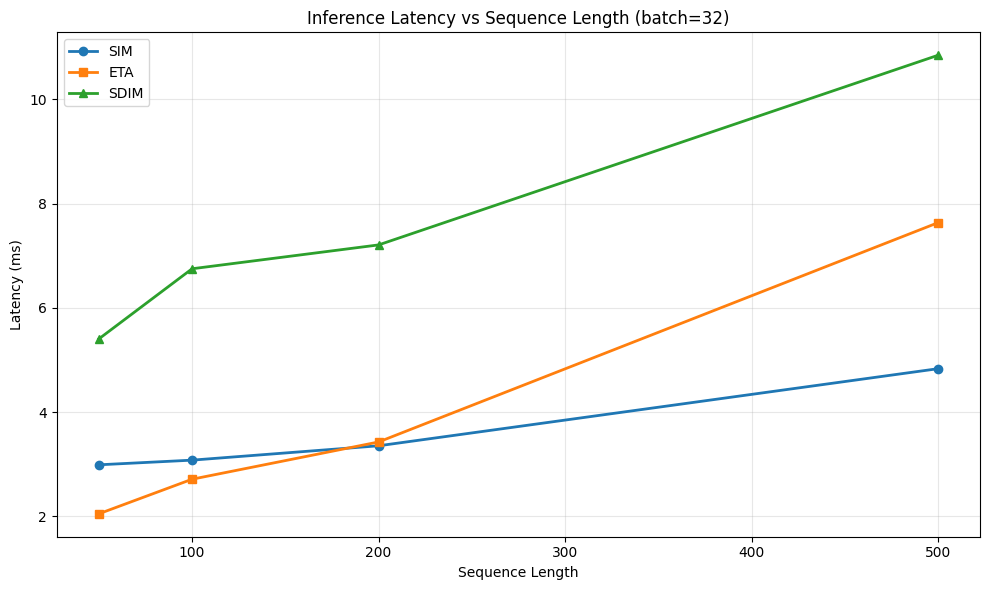

In [7]:
def benchmark_model(model_fn, seq_lengths, batch_size=32, num_runs=5):
    """Benchmark model inference latency across sequence lengths."""
    latencies = []
    for seq_len in seq_lengths:
        items = torch.randint(0, NUM_ITEMS, (batch_size, seq_len))
        target = torch.randint(0, NUM_ITEMS, (batch_size,))
        mask = torch.ones(batch_size, seq_len)
        
        times = []
        for _ in range(num_runs):
            start = time.time()
            with torch.no_grad():
                model_fn(items, target, mask)
            times.append(time.time() - start)
        latencies.append(np.mean(times) * 1000)  # Convert to ms
    return latencies


seq_lengths = [50, 100, 200, 500]

# Benchmark each model
eta_model = ETA(NUM_ITEMS, EMBED_DIM, top_k=50)
eta_model.eval()
sdim_model = SDIM(NUM_ITEMS, EMBED_DIM, sample_size=50)
sdim_model.eval()

eta_latencies = benchmark_model(eta_model, seq_lengths)
sdim_latencies = benchmark_model(sdim_model, seq_lengths)

# SIM wrapper (needs cats)
sim_model = SIM(NUM_ITEMS, NUM_CATEGORIES, EMBED_DIM, top_k=50)
sim_model.eval()

def sim_fn(items, target, mask):
    cats = torch.randint(0, NUM_CATEGORIES, items.shape)
    target_cat = torch.randint(0, NUM_CATEGORIES, target.shape)
    return sim_model(items, cats, target, target_cat, mask)

sim_latencies = benchmark_model(sim_fn, seq_lengths)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(seq_lengths, sim_latencies, 'o-', label='SIM', linewidth=2)
ax.plot(seq_lengths, eta_latencies, 's-', label='ETA', linewidth=2)
ax.plot(seq_lengths, sdim_latencies, '^-', label='SDIM', linewidth=2)

ax.set_xlabel('Sequence Length')
ax.set_ylabel('Latency (ms)')
ax.set_title('Inference Latency vs Sequence Length (batch=32)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. UBR4CTR: User Behavior Retrieval

UBR4CTR (User Behavior Retrieval for CTR, 2020) treats long-term behavior modeling as a retrieval problem. Instead of processing all behaviors during model inference, it pre-indexes user behaviors and retrieves relevant ones at query time.

### Architecture

1. **Offline indexing**: Build an inverted index of user behaviors keyed by item attributes
2. **Online retrieval**: Given a target item, retrieve relevant behaviors via attribute matching
3. **CTR model**: Standard attention-based CTR model on retrieved behaviors

> **💡 Concept:** UBR4CTR separates the retrieval of relevant behaviors from CTR computation, allowing the retrieval component to be optimized independently (e.g., with a learned retrieval model).

In [8]:
class UBR4CTR(nn.Module):
    """User Behavior Retrieval for CTR prediction."""
    def __init__(self, num_items: int, num_categories: int, embed_dim: int,
                 retrieval_k: int = 30):
        super().__init__()
        self.retrieval_k = retrieval_k
        self.item_embedding = nn.Embedding(num_items, embed_dim)
        self.cat_embedding = nn.Embedding(num_categories, embed_dim)
        
        # Learned retrieval scoring
        self.retrieval_scorer = nn.Sequential(
            nn.Linear(embed_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
        # CTR attention
        self.attention = nn.MultiheadAttention(embed_dim, num_heads=4, batch_first=True)
        
        self.output_mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, behavior_items, behavior_cats, target_item, target_cat, behavior_mask):
        batch_size, seq_len = behavior_items.shape
        
        # Compute retrieval scores
        behav_cat_embeds = self.cat_embedding(behavior_cats)  # (batch, seq, dim)
        target_cat_embed = self.cat_embedding(target_cat).unsqueeze(1).expand_as(behav_cat_embeds)
        retrieval_input = torch.cat([behav_cat_embeds, target_cat_embed], dim=-1)
        retrieval_scores = self.retrieval_scorer(retrieval_input).squeeze(-1)  # (batch, seq)
        retrieval_scores = retrieval_scores * behavior_mask + (1 - behavior_mask) * (-1e9)
        
        # Retrieve top-k
        k = min(self.retrieval_k, seq_len)
        _, topk_idx = torch.topk(retrieval_scores, k, dim=1)
        
        topk_items = torch.gather(behavior_items, 1, topk_idx)
        topk_embeds = self.item_embedding(topk_items)  # (batch, k, dim)
        
        # Self-attention on retrieved behaviors
        target_embed = self.item_embedding(target_item).unsqueeze(1)  # (batch, 1, dim)
        attn_out, _ = self.attention(target_embed, topk_embeds, topk_embeds)
        user_interest = attn_out.squeeze(1)  # (batch, dim)
        
        combined = torch.cat([user_interest, target_embed.squeeze(1)], dim=-1)
        return self.output_mlp(combined).squeeze(-1)


model_ubr = UBR4CTR(NUM_ITEMS, NUM_CATEGORIES, EMBED_DIM)
logits = model_ubr(batch_items, batch_cats, batch_target, batch_target_cat, batch_mask)
print(f"UBR4CTR output shape: {logits.shape}")
print(f"UBR4CTR parameters: {sum(p.numel() for p in model_ubr.parameters()):,}")

UBR4CTR output shape: torch.Size([16])
UBR4CTR parameters: 178,498


## 8. Model Comparison: Training on Synthetic Data

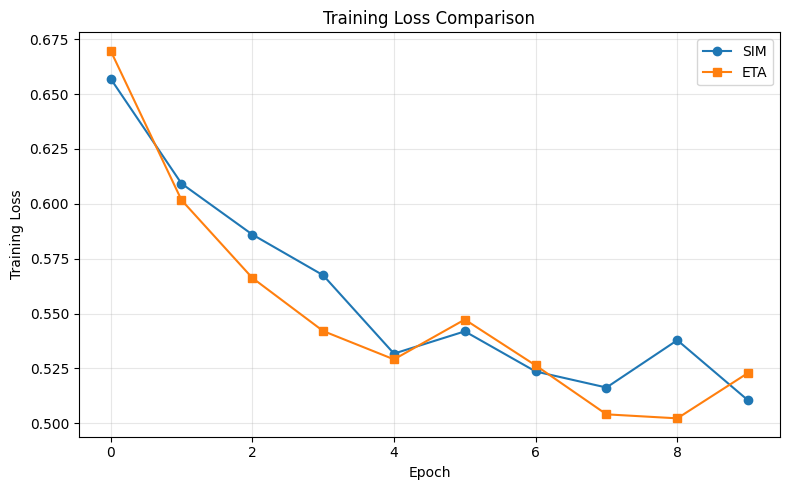

In [9]:
def prepare_batch_data(user_histories, target_items, target_categories, labels,
                       max_seq_len=200, num_items=5000, num_categories=50):
    """Prepare padded batch data from user histories."""
    n = len(labels)
    all_items = torch.zeros(n, max_seq_len, dtype=torch.long)
    all_cats = torch.zeros(n, max_seq_len, dtype=torch.long)
    all_masks = torch.zeros(n, max_seq_len)
    
    for uid in range(n):
        hist = user_histories[uid]
        seq_len = min(len(hist), max_seq_len)
        for t in range(seq_len):
            all_items[uid, t] = hist[t][0]
            all_cats[uid, t] = hist[t][1]
            all_masks[uid, t] = 1.0
    
    return (all_items, all_cats, all_masks,
            torch.LongTensor(target_items),
            torch.LongTensor(target_categories),
            torch.FloatTensor(labels))


data = prepare_batch_data(user_histories, target_items, target_categories, labels)
all_items, all_cats, all_masks, all_targets, all_target_cats, all_labels = data

# Quick training comparison
def quick_train(model, forward_fn, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    losses = []
    n = len(all_labels)
    batch_size = 128
    
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        total_loss = 0
        count = 0
        for i in range(0, min(n, 512), batch_size):  # Use subset for speed
            idx = perm[i:i+batch_size]
            optimizer.zero_grad()
            logits = forward_fn(model, idx)
            loss = criterion(logits, all_labels[idx])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            count += 1
        losses.append(total_loss / max(count, 1))
    return losses


def sim_forward(model, idx):
    logits, _ = model(all_items[idx], all_cats[idx], all_targets[idx], all_target_cats[idx], all_masks[idx])
    return logits

def eta_forward(model, idx):
    return model(all_items[idx], all_targets[idx], all_masks[idx])

torch.manual_seed(42)
sim_losses = quick_train(SIM(NUM_ITEMS, NUM_CATEGORIES, EMBED_DIM), sim_forward)
torch.manual_seed(42)
eta_losses = quick_train(ETA(NUM_ITEMS, EMBED_DIM), eta_forward)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sim_losses, 'o-', label='SIM')
ax.plot(eta_losses, 's-', label='ETA')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Implement SIM's General Search Unit (GSU) with Learned Hashing

Extend the GSU to use a learned hash function instead of raw inner products for more efficient retrieval.

In [10]:
class LearnedHashGSU(nn.Module):
    """GSU with learned hashing for efficient retrieval.
    
    Instead of computing inner products between all behaviors and the target,
    learn a hash function that maps similar items to the same bucket.
    """
    def __init__(self, num_items: int, embed_dim: int, num_hash_bits: int = 16, top_k: int = 50):
        super().__init__()
        # TODO: Implement learned hash function
        # 1. Item embedding layer
        # 2. Hash projection network (embedding -> hash_bits)
        # 3. Straight-through estimator for binary hash codes
        pass
    
    def forward(self, behavior_items, target_item, behavior_mask):
        # TODO: Implement forward pass
        # 1. Compute hash codes for behavior and target items
        # 2. Compute Hamming similarity
        # 3. Select top-k most similar
        # Return: retrieved_embeds, retrieved_mask, search_scores
        pass


# Test: gsu = LearnedHashGSU(5000, 32)
# retrieved, mask, scores = gsu(batch_items, batch_target, batch_mask)

### 🏋️ Exercise 2: Implement Multi-Head Target Attention ESU

Extend the ESU to use multi-head attention for richer interest extraction.

In [11]:
class MultiHeadESU(nn.Module):
    """Multi-head version of the Exact Search Unit.
    
    Each head captures a different aspect of user interest
    with respect to the target item.
    """
    def __init__(self, embed_dim: int, num_heads: int = 4):
        super().__init__()
        # TODO: Implement multi-head target attention
        # 1. Project queries (target) and keys/values (behaviors) per head
        # 2. Compute scaled dot-product attention per head
        # 3. Concatenate and project heads
        pass
    
    def forward(self, retrieved_embeds, target_embed, mask):
        # TODO: Implement forward pass
        pass


# Test: esu = MultiHeadESU(32, num_heads=4)
# interest = esu(torch.randn(16, 50, 32), torch.randn(16, 32), torch.ones(16, 50))

### 🏋️ Exercise 3: Implement HPMN-style Hierarchical Memory

Implement a hierarchical memory that captures interests at different time scales.

In [12]:
class HierarchicalMemory(nn.Module):
    """HPMN-inspired hierarchical memory network.
    
    Multiple memory levels capture interests at different time scales:
    - Level 0: Short-term (recent behaviors)
    - Level 1: Medium-term (weekly patterns)
    - Level 2: Long-term (persistent preferences)
    
    Higher levels update less frequently (every k^level steps).
    """
    def __init__(self, embed_dim: int, num_levels: int = 3,
                 memory_size: int = 4, update_period: int = 5):
        super().__init__()
        # TODO: Implement hierarchical memory
        # 1. Create GRU cells for each level
        # 2. Implement periodic update logic
        # 3. Implement attention-based readout across levels
        pass
    
    def update(self, memory_states, behavior_embed, step):
        # TODO: Update memories at appropriate levels based on step
        pass
    
    def read(self, memory_states, target_embed):
        # TODO: Read from all levels and combine
        pass

### 🏋️ Exercise 4: Compare Retrieval Quality

Implement a function to measure how well different retrieval methods (SIM, ETA, SDIM) recover the truly relevant behaviors.

In [13]:
def evaluate_retrieval_quality(retrieval_fn, behavior_items, behavior_cats,
                                target_items, target_cats, k=50):
    """Evaluate retrieval quality using category-match precision and recall.
    
    Args:
        retrieval_fn: Function that returns retrieved item indices
        behavior_items: (batch, seq_len)
        behavior_cats: (batch, seq_len) 
        target_items: (batch,)
        target_cats: (batch,)
        k: number of items to retrieve
    
    Returns:
        precision: fraction of retrieved items matching target category
        recall: fraction of same-category items that were retrieved
    """
    # TODO: Implement retrieval quality evaluation
    # 1. Get retrieved indices from retrieval_fn
    # 2. Check how many retrieved items share category with target
    # 3. Compute precision and recall
    pass


# TODO: Compare SIM (hard), SIM (soft), ETA, and SDIM retrieval quality
# Plot precision@k and recall@k for different k values

## Summary

In this notebook, we explored methods for modeling long user behavior sequences:

| Model | Key Idea | Complexity | Paper |
|-------|----------|------------|-------|
| **SIM** | Two-stage: search then attend | $O(n + k^2)$ | Alibaba, 2020 |
| **ETA** | SimHash-based target attention | $O(n)$ | 2021 |
| **SDIM** | Multi-round hash sampling | $O(n)$ | 2022 |
| **MIMN** | External memory network | $O(m)$ per step | Alibaba, 2019 |
| **UBR4CTR** | Retrieval-based approach | $O(n + k)$ | 2020 |

**Key takeaways:**
- Long user histories contain valuable signals but are expensive to process
- Two-stage approaches (search + model) offer the best accuracy-latency trade-off
- Hash-based methods provide near-linear complexity with competitive accuracy
- Memory networks enable incremental updates without reprocessing